# Chelsy Wandellice - 2802412534

### Dataset: data_D.csv  
* Jumlah data: 25.000 baris
* Jumlah fitur: 29 kolom
* Target: Credit_Score (Poor, Standard, Good)  
Ini adalah masalah klasifikasi multiclass.

---

**Import Libraries**

In [5]:
import warnings
warnings.filterwarnings("ignore")

import re
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


**Set Seed**

In [6]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

**Load Dataset**

In [7]:
df = pd.read_csv("data_D.csv")

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")

display(df.head())

Dataset Loaded Successfully
Dataset Shape : (25000, 29)


,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0x20c27,CUS_0xf64,June,NaN,32,478-73-8323,Doctor,56125.5,4875.12,8,3,18,2,"Credit-Builder Loan, and Mortgage Loan",30,14,17.89,4.00,Standard,370.22,32.01,28 Years and 10 Months,Yes,81.82,182.06551022025016,High_spent_Medium_value_payments,473.62413320457887,Standard
1,1,0xc518,CUS_0x697f,March,Philh,39,367-66-5050,Entrepreneur,62148.0,NaN,9,7,24,5,"Mortgage Loan, Personal Loan, Payday Loan, Per...",56,25,_,8.00,Bad,2373.61,33.95,16 Years and 6 Months,Yes,258.85,195.3722153038279,High_spent_Small_value_payments,300.6789235920986,Poor
2,2,0x22663,CUS_0x7846,February,Paramadithak,45,282-14-9365,Accountant,88380.16,7471.01,7,7,19,3,"Student Loan, Home Equity Loan, and Credit-Bui...",11,19,8.7,5.00,_,124.29,41.02,NaN,Yes,129.72,180.79874191787297,High_spent_Medium_value_payments,686.5788927990964,Standard
3,3,0x1ff7,CUS_0x3ef5,June,Robinsonl,32,259-09-9023,_______,7821.24,468.77,8,10,29,6,"Mortgage Loan, Personal Loan, Home Equity Loan...",62,17,19.34,7.00,Bad,2924.76,34.20,10 Years and 2 Months,Yes,19.73,39.93770264234067,Low_spent_Medium_value_payments,267.2113738653678,Standard
4,4,0x9a07,CUS_0x8fdf,June,Yeeo,18,312-56-4208,Scientist,107871.9,NaN,3,4,8,3,"Student Loan, Mortgage Loan, and Credit-Builde...",25,20,11.27,2.00,Standard,1005.83,27.24,32 Years and 8 Months,No,227.24,73.48570828760295,High_spent_Large_value_payments,820.9050026625811,Standard


**Dataset Overview**

In [8]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(25000, 29)


Terdapat 25.000 data dengan 29 atribut

In [9]:
print("\nColumns")
for index, column in enumerate(df.columns, start=1):
    print(f"{index:02d}. {column}")


Columns
01. Unnamed: 0
02. ID
03. Customer_ID
04. Month
05. Name
06. Age
07. SSN
08. Occupation
09. Annual_Income
10. Monthly_Inhand_Salary
11. Num_Bank_Accounts
12. Num_Credit_Card
13. Interest_Rate
14. Num_of_Loan
15. Type_of_Loan
16. Delay_from_due_date
17. Num_of_Delayed_Payment
18. Changed_Credit_Limit
19. Num_Credit_Inquiries
20. Credit_Mix
21. Outstanding_Debt
22. Credit_Utilization_Ratio
23. Credit_History_Age
24. Payment_of_Min_Amount
25. Total_EMI_per_month
26. Amount_invested_monthly
27. Payment_Behaviour
28. Monthly_Balance
29. Credit_Score


In [10]:
print("\nDataset Information")
df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                25000 non-null  int64  
 1   ID                        25000 non-null  object 
 2   Customer_ID               25000 non-null  object 
 3   Month                     25000 non-null  object 
 4   Name                      22471 non-null  object 
 5   Age                       25000 non-null  object 
 6   SSN                       25000 non-null  object 
 7   Occupation                25000 non-null  object 
 8   Annual_Income             25000 non-null  object 
 9   Monthly_Inhand_Salary     21173 non-null  float64
 10  Num_Bank_Accounts         25000 non-null  int64  
 11  Num_Credit_Card           25000 non-null  int64  
 12  Interest_Rate             25000 non-null  int64  
 13  Num_of_Loan               25000 non-null

Ada beberapa atribut yang memiliki missing value serta data type yang tidak sesuai dengan value atribut. Ada juga kolom yang tidak diperlukan dalam analisis seperti ID.

**Descriptive Statistic**

In [11]:
print("Numerical Features")
display(df.describe())

Numerical Features


,Unnamed: 0,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,25000.00,21173.00,25000.00,25000.00,25000.00,25000.00,24503.00,25000.00,25000.00
mean,12499.50,4168.31,16.86,23.31,70.36,21.07,26.94,32.27,1440.04
std,7217.02,3170.87,114.77,133.62,458.47,14.89,189.25,5.11,8514.91
min,0.00,303.65,-1.00,0.00,1.00,-5.00,0.00,20.00,0.00
25%,6249.75,1625.27,4.00,4.00,8.00,10.00,3.00,28.06,29.91
50%,12499.50,3080.35,6.00,5.00,13.00,18.00,6.00,32.33,68.78
75%,18749.25,5927.53,8.00,7.00,20.00,28.00,9.00,36.48,160.18
max,24999.00,15204.63,1794.00,1499.00,5789.00,67.00,2553.00,49.56,82122.00


In [12]:
print("Categorical Features")
display(df.describe(include="object"))

Categorical Features


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,25000,25000,25000,22471,25000,25000,25000,25000,25000,22120,23256,25000,25000,25000,22751,25000,23879,25000,24691,25000
unique,25000,11199,8,9014,548,11024,16,12749,131,5690,241,3395,4,11187,403,3,22751,7,24689,3
top,0x10d0c,CUS_0x8727,August,Deepa Seetharamanm,27,#F%$D@*&8,_______,29020.78,3,Not Specified,17,_,Standard,967.75,19 Years and 5 Months,Yes,__10000__,Low_spent_Small_value_payments,__-333333333333333333333333333__,Standard
freq,1,8,3189,16,708,1397,1735,8,3610,341,1367,523,9097,11,127,13041,1092,6331,3,13305


**Missing Value**

In [13]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Percentage (%)": (
        df.isna().mean() * 100
    ).round(2)
})

missing = (
    missing
    .sort_values(
        by="Missing Count",
        ascending=False
    )
)

display(missing)

,Missing Count,Percentage (%)
Monthly_Inhand_Salary,3827,15.31
Type_of_Loan,2880,11.52
Name,2529,10.12
Credit_History_Age,2249,9.00
Num_of_Delayed_Payment,1744,6.98
...,...,...
Credit_Utilization_Ratio,0,0.00
Total_EMI_per_month,0,0.00
Payment_of_Min_Amount,0,0.00
Payment_Behaviour,0,0.00


**Missing Value Visualization**

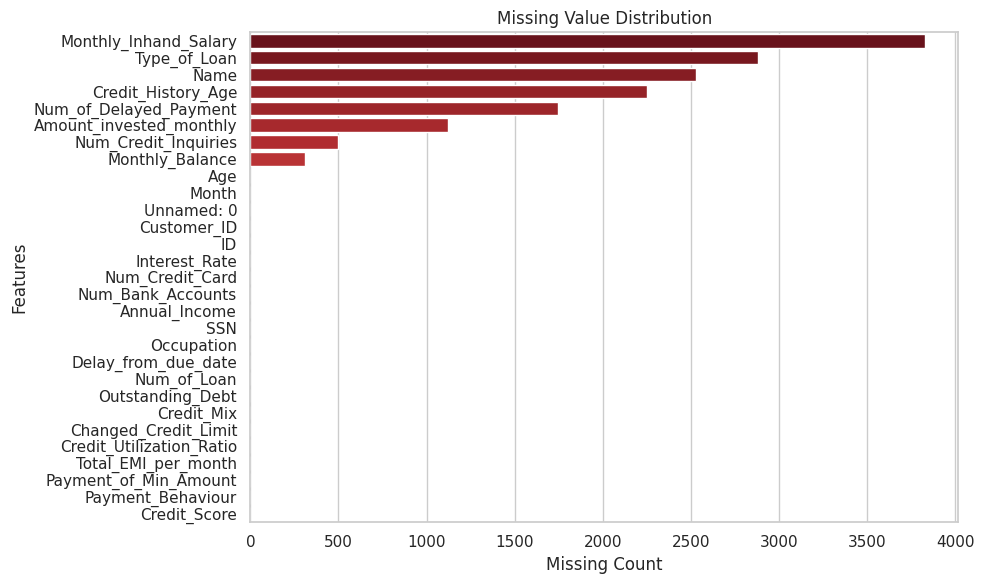

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=missing.reset_index(),
    x="Missing Count",
    y="index",
    palette="Reds_r"
)

plt.title("Missing Value Distribution")
plt.xlabel("Missing Count")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

**Duplicate Records**

In [15]:
duplicate = df.duplicated().sum()
print(f"Total Duplicate Records : {duplicate}")

Total Duplicate Records : 0


**Target Distribution**

,count
Credit_Score,
Standard,13305
Poor,7231
Good,4464


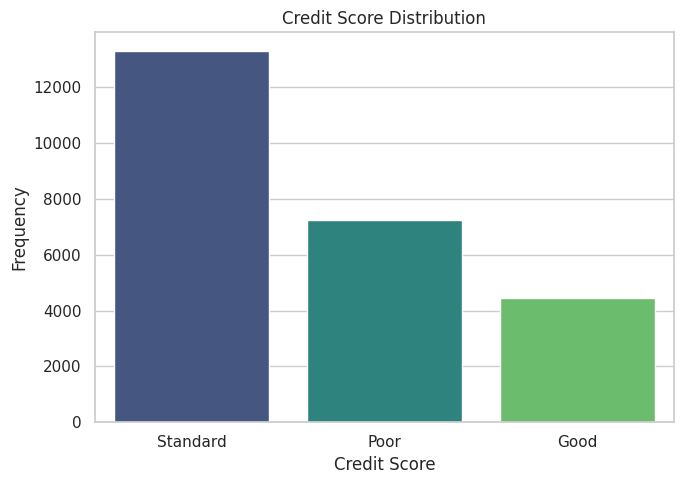

In [16]:
display(df["Credit_Score"].value_counts())

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Credit_Score",
    palette="viridis"
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Numerical Features**

In [17]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical Features")

display(pd.DataFrame(
    numeric_columns,
    columns=["Feature"]
))

Numerical Features


,Feature
0,Unnamed: 0
1,Monthly_Inhand_Salary
2,Num_Bank_Accounts
3,Num_Credit_Card
4,Interest_Rate
5,Delay_from_due_date
6,Num_Credit_Inquiries
7,Credit_Utilization_Ratio
8,Total_EMI_per_month


**Categorical Features**

In [18]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

print("Categorical Features")

display(pd.DataFrame(
    categorical_columns,
    columns=["Feature"]
))

Categorical Features


,Feature
0,ID
1,Customer_ID
2,Month
3,Name
4,Age
5,SSN
6,Occupation
7,Annual_Income
8,Num_of_Loan
9,Type_of_Loan


**Identify Dirty Data**  
Dataset ini tidak hanya memiliki missing value, tetapi juga memiliki invalid value.  

List Anomali:
* Occupation: _______
* Credit Mix: _
* Payment Behaviour: !@9#%8
* Age: -500, 9999, 52_
* Annual Income: 32411.63_
* Outstanding Debt: 1340.52_
* Monthly Balance: _ -3333333333333 _
* Amount Invested Monthly: _ 10000 _
* Payment of Min Amount: NM
* Changed Credit Limit: _, -3.22
* Delay From Due Date: -4, -5

In [19]:
print("Occupation")
display(df["Occupation"].value_counts(dropna=False).head(15))

print("\nCredit Mix")
display(df["Credit_Mix"].value_counts(dropna=False))

print("\nPayment Behaviour")
display(df["Payment_Behaviour"].value_counts(dropna=False))

print("\nPayment of Minimum Amount")
display(df["Payment_of_Min_Amount"].value_counts(dropna=False))

print("\Age")
display(df["Age"].unique()[:20])

print("\nAnnual Income")
display(df["Annual_Income"].sample(20))

print("\nOutstanding Debt")
display(df["Outstanding_Debt"].value_counts(dropna=False))

print("\Monthly Balance")
display(df["Monthly_Balance"].value_counts(dropna=False))

print("\nMonth")
display(df["Month"].value_counts())

print("\nAmount Invested Monthly")
display(df["Amount_invested_monthly"].sample(20))

Occupation


,count
Occupation,
_______,1735
Lawyer,1681
Architect,1622
Developer,1588
Scientist,1580
Mechanic,1579
Engineer,1579
Accountant,1557
Doctor,1555



Credit Mix


,count
Credit_Mix,
Standard,9097
Good,6166
_,5031
Bad,4706



Payment Behaviour


...

,count
Monthly_Balance,
NaN,309
__-333333333333333333333333333__,3
965.7896156237416,1
234.49594087893885,1
372.71300697793856,1
...,...
494.22401935272484,1
442.9198108820122,1
3.998674636139072,1



Month


,count
Month,
August,3189
June,3167
January,3154
May,3152
April,3137
July,3112
February,3104
March,2985



Amount Invested Monthly


,Amount_invested_monthly
17423,317.4897350838796
14441,67.41168488453572
20743,536.4389754629883
3253,138.3816247643756
7503,271.86470718805685
6083,82.62669095811479
22629,407.90229130196656
19641,37.98396101614559
23882,35.39600934107116
19055,274.4629564756812


**Numeric Column Stored as Object**

In [20]:
object_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("Object Columns")

for column in object_columns:
    print(column)

Object Columns
ID
Customer_ID
Month
Name
Age
SSN
Occupation
Annual_Income
Num_of_Loan
Type_of_Loan
Num_of_Delayed_Payment
Changed_Credit_Limit
Credit_Mix
Outstanding_Debt
Credit_History_Age
Payment_of_Min_Amount
Amount_invested_monthly
Payment_Behaviour
Monthly_Balance
Credit_Score


**Data Cleaning**

In [21]:
#Create Backup
df_clean = df.copy()

print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

print(f"Original Shape : {df_clean.shape}")

DATA CLEANING
Original Shape : (25000, 29)


**Remove Identifier Columns**

In [22]:
identifier_columns = [
    "Unnamed: 0",
    "ID",
    "Customer_ID",
    "Name",
    "SSN"
]

df_clean.drop(
    columns=identifier_columns,
    inplace=True,
    errors="ignore"
)

print(f"Remaining Features : {df_clean.shape[1]}")

Remaining Features : 24


Beberapa kolom seperti ID dan Customer_ID merupakan identifier, sedangkan Unnamed:0, Name, dan SSN merupakan index. Kelima kolom ini tidak akan membantu dalam proses analisis skor credit nanti.

Kalau dibiarkan, hanya akan menimbulkan overfitting

**Replace Hidden Missing Value**

In [23]:
hidden_missing = [
    "_______",
    "_",
    "!@9#%8",
    "NM"
]

df_clean.replace(
    hidden_missing,
    np.nan,
    inplace=True
)

print("Hidden missing values replaced successfully.")

Hidden missing values replaced successfully.


**Convert Numeric Columns Stored as Object**

In [24]:
numeric_object_columns = [
    "Age",
    "Annual_Income",
    "Num_of_Loan",
    "Num_of_Delayed_Payment",
    "Changed_Credit_Limit",
    "Outstanding_Debt",
    "Amount_invested_monthly",
    "Monthly_Balance"
]

for column in numeric_object_columns:

    df_clean[column] = (
        df_clean[column]
        .astype(str)
        .str.replace("_", "", regex=False)
        .str.strip()
    )

    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

print("Numeric conversion completed.")

Numeric conversion completed.


**Convert Credit History Age**

In [25]:
def convert_credit_history(value):
    if pd.isna(value):
        return np.nan

    match = re.search(
        r"(\d+)\s+Years?\s+and\s+(\d+)\s+Months?",
        str(value)
    )

    if match:
        years = int(match.group(1))
        months = int(match.group(2))
        return years * 12 + months

    return np.nan

df_clean["Credit_History_Age"] = (
    df_clean["Credit_History_Age"]
    .apply(convert_credit_history)
)

print("Credit history converted into months.")

Credit history converted into months.


**Clean Invalid Values**

In [26]:
# Age
df_clean.loc[
    (df_clean["Age"] < 18) |
    (df_clean["Age"] > 100),
    "Age"
] = np.nan

# Annual Income
df_clean.loc[
    df_clean["Annual_Income"] <= 0,
    "Annual_Income"
] = np.nan

# Number of Loans
df_clean.loc[
    df_clean["Num_of_Loan"] < 0,
    "Num_of_Loan"
] = np.nan

# Number of Delayed Payment
df_clean.loc[
    df_clean["Num_of_Delayed_Payment"] < 0,
    "Num_of_Delayed_Payment"
] = np.nan

# Changed Credit Limit
df_clean.loc[
    df_clean["Changed_Credit_Limit"] < 0,
    "Changed_Credit_Limit"
] = np.nan

# Outstanding Debt
df_clean.loc[
    df_clean["Outstanding_Debt"] < 0,
    "Outstanding_Debt"
] = np.nan

# Monthly Balance
df_clean.loc[
    df_clean["Monthly_Balance"] < 0,
    "Monthly_Balance"
] = np.nan

# Amount Invested Monthly
df_clean.loc[
    df_clean["Amount_invested_monthly"] < 0,
    "Amount_invested_monthly"
] = np.nan

# Delay From Due Date
df_clean["Delay_from_due_date"] = (
    df_clean["Delay_from_due_date"]
    .clip(lower=0)
)

print("Invalid values cleaned.")

Invalid values cleaned.


**Remove Extreme Outliers**

In [27]:
Q1 = df_clean["Amount_invested_monthly"].quantile(0.25)
Q3 = df_clean["Amount_invested_monthly"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean.loc[
    (
        df_clean["Amount_invested_monthly"] < lower_bound
    ) |
    (
        df_clean["Amount_invested_monthly"] > upper_bound
    ),
    "Amount_invested_monthly"
] = np.nan

print("Extreme investment outliers handled.")

Extreme investment outliers handled.


**Missing Value Summary**

In [28]:
missing_summary = pd.DataFrame({
    "Missing Count": df_clean.isna().sum(),
    "Percentage (%)": (
        df_clean.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary
    .sort_values(
        by="Missing Count",
        ascending=False
    )
)

display(missing_summary)

,Missing Count,Percentage (%)
Credit_Mix,5031,20.12
Monthly_Inhand_Salary,3827,15.31
Amount_invested_monthly,3660,14.64
Payment_of_Min_Amount,2978,11.91
Type_of_Loan,2880,11.52
...,...,...
Delay_from_due_date,0,0.00
Outstanding_Debt,0,0.00
Credit_Utilization_Ratio,0,0.00
Total_EMI_per_month,0,0.00


**Data Type Validation**

In [29]:
dtype_summary = pd.DataFrame({
    "Data Type": df_clean.dtypes
})

display(dtype_summary)

,Data Type
Month,object
Age,float64
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
...,...
Total_EMI_per_month,float64
Amount_invested_monthly,float64
Payment_Behaviour,object
Monthly_Balance,float64


**Numerical Validation**

In [30]:
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,22936.00,34.55,10.15,18.00,26.00,34.00,42.00,100.00
Annual_Income,25000.00,166641.83,1352158.43,7005.93,19536.45,37404.67,72413.14,24198062.00
Monthly_Inhand_Salary,21173.00,4168.31,3170.87,303.65,1625.27,3080.35,5927.53,15204.63
Num_Bank_Accounts,25000.00,16.86,114.77,-1.00,4.00,6.00,8.00,1794.00
Num_Credit_Card,25000.00,23.31,133.62,0.00,4.00,5.00,7.00,1499.00
Interest_Rate,25000.00,70.36,458.47,1.00,8.00,13.00,20.00,5789.00
Num_of_Loan,24068.00,7.19,61.79,0.00,2.00,3.00,5.00,1485.00
Delay_from_due_date,25000.00,21.08,14.87,0.00,10.00,18.00,28.00,67.00
Num_of_Delayed_Payment,23076.00,30.32,218.30,0.00,9.00,14.00,18.00,4340.00
Changed_Credit_Limit,24089.00,10.63,6.65,0.00,5.62,9.50,15.03,36.97


**Categorical Validation**

In [31]:
categorical_columns = df_clean.select_dtypes(
    include="object"
).columns

for column in categorical_columns:

    print("=" * 60)

    print(column)

    print("=" * 60)

    display(
        df_clean[column]
        .value_counts(dropna=False)
        .head(20)
    )

Month


,count
Month,
August,3189
June,3167
January,3154
May,3152
April,3137
July,3112
February,3104
March,2985


Occupation


,count
Occupation,
NaN,1735
Lawyer,1681
Architect,1622
Developer,1588
Scientist,1580
Mechanic,1579
Engineer,1579
Accountant,1557
Doctor,1555


Type_of_Loan


...

,count
Payment_of_Min_Amount,
Yes,13041
No,8981
NaN,2978


Payment_Behaviour


,count
Payment_Behaviour,
Low_spent_Small_value_payments,6331
High_spent_Medium_value_payments,4300
High_spent_Large_value_payments,3561
Low_spent_Medium_value_payments,3455
High_spent_Small_value_payments,2864
Low_spent_Large_value_payments,2595
NaN,1894


Credit_Score


,count
Credit_Score,
Standard,13305
Poor,7231
Good,4464


**Final Range Validation**

In [32]:
numeric_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

validation = pd.DataFrame({
    "Minimum": df_clean[numeric_columns].min(),
    "Maximum": df_clean[numeric_columns].max(),
    "Missing": df_clean[numeric_columns].isna().sum()
})

display(validation)

,Minimum,Maximum,Missing
Age,18.00,100.00,2064
Annual_Income,7005.93,24198062.00,0
Monthly_Inhand_Salary,303.65,15204.63,3827
Num_Bank_Accounts,-1.00,1794.00,0
Num_Credit_Card,0.00,1499.00,0
Interest_Rate,1.00,5789.00,0
Num_of_Loan,0.00,1485.00,932
Delay_from_due_date,0.00,67.00,0
Num_of_Delayed_Payment,0.00,4340.00,1924
Changed_Credit_Limit,0.00,36.97,911


**Save Cleaned Dataset**

In [33]:
df_clean.to_csv(
    "cleaned_credit_score.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


**Data Validation & Exploratory Data Analysis**

**Dataset Cleaned Overview**

In [34]:
print(f"Dataset Shape : {df_clean.shape}")
display(df_clean.head())

Dataset Shape : (25000, 24)


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,June,32.00,Doctor,56125.50,4875.12,8,3,18,2.00,"Credit-Builder Loan, and Mortgage Loan",30,14.00,17.89,4.00,Standard,370.22,32.01,346.00,Yes,81.82,182.07,High_spent_Medium_value_payments,473.62,Standard
1,March,39.00,Entrepreneur,62148.00,NaN,9,7,24,5.00,"Mortgage Loan, Personal Loan, Payday Loan, Per...",56,25.00,NaN,8.00,Bad,2373.61,33.95,198.00,Yes,258.85,195.37,High_spent_Small_value_payments,300.68,Poor
2,February,45.00,Accountant,88380.16,7471.01,7,7,19,3.00,"Student Loan, Home Equity Loan, and Credit-Bui...",11,19.00,8.70,5.00,NaN,124.29,41.02,NaN,Yes,129.72,180.80,High_spent_Medium_value_payments,686.58,Standard
3,June,32.00,NaN,7821.24,468.77,8,10,29,6.00,"Mortgage Loan, Personal Loan, Home Equity Loan...",62,17.00,19.34,7.00,Bad,2924.76,34.20,122.00,Yes,19.73,39.94,Low_spent_Medium_value_payments,267.21,Standard
4,June,18.00,Scientist,107871.90,NaN,3,4,8,3.00,"Student Loan, Mortgage Loan, and Credit-Builde...",25,20.00,11.27,2.00,Standard,1005.83,27.24,392.00,No,227.24,73.49,High_spent_Large_value_payments,820.91,Standard


**Check Missing Value**

In [35]:
missing_summary = (
    pd.DataFrame({
        "Missing Count": df_clean.isna().sum(),
        "Percentage (%)": (
            df_clean.isna().mean() * 100
        ).round(2)
    })
    .sort_values(
        by="Missing Count",
        ascending=False
    )
)

display(missing_summary)

,Missing Count,Percentage (%)
Credit_Mix,5031,20.12
Monthly_Inhand_Salary,3827,15.31
Amount_invested_monthly,3660,14.64
Payment_of_Min_Amount,2978,11.91
Type_of_Loan,2880,11.52
...,...,...
Delay_from_due_date,0,0.00
Outstanding_Debt,0,0.00
Credit_Utilization_Ratio,0,0.00
Total_EMI_per_month,0,0.00


**Correlation Matrix**

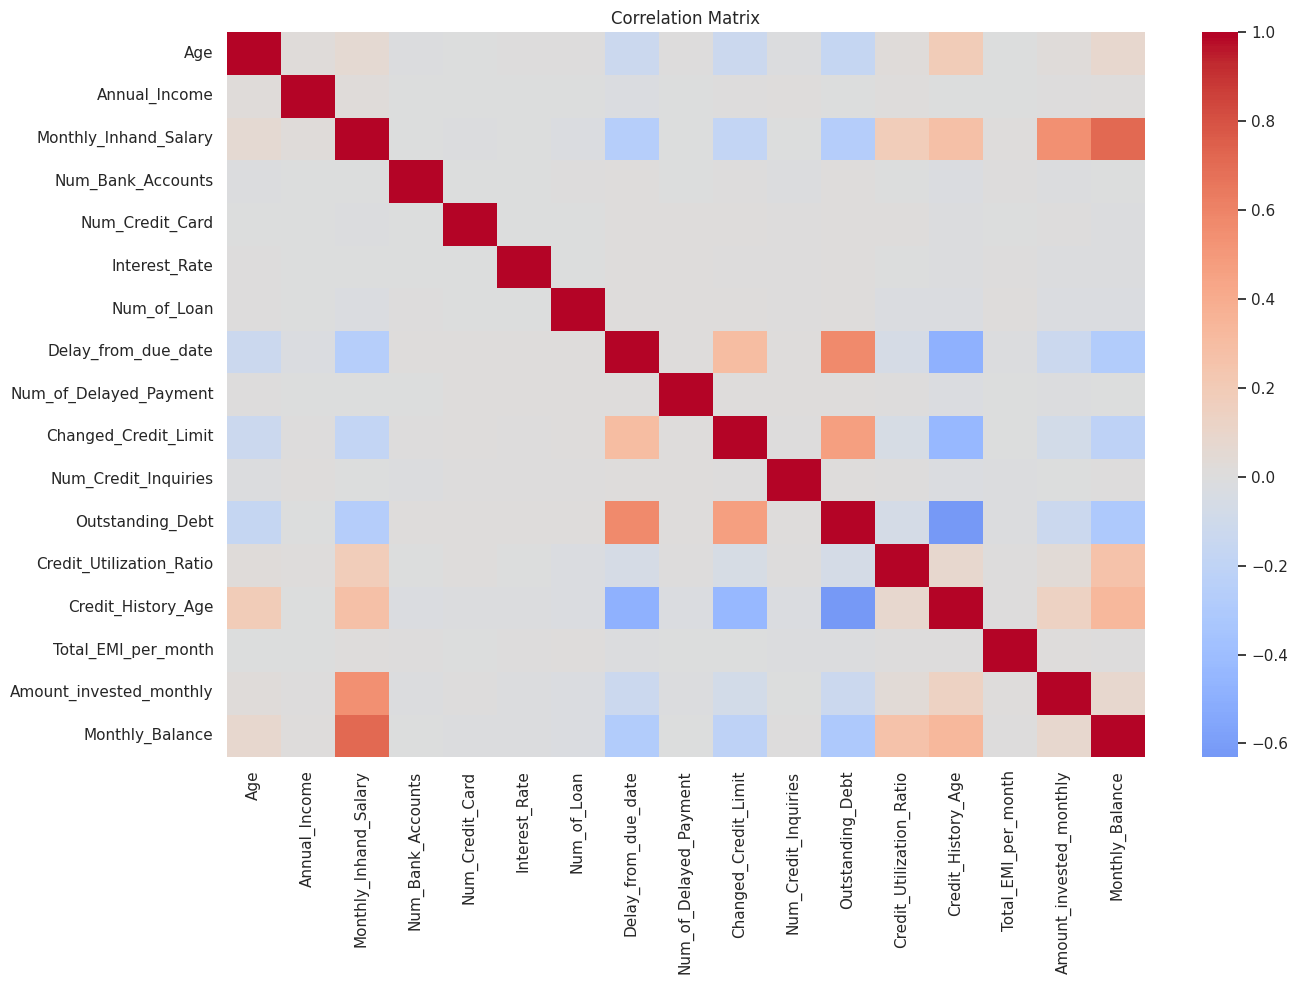

In [36]:
numeric_data = df_clean.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_data.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

**Visualization**

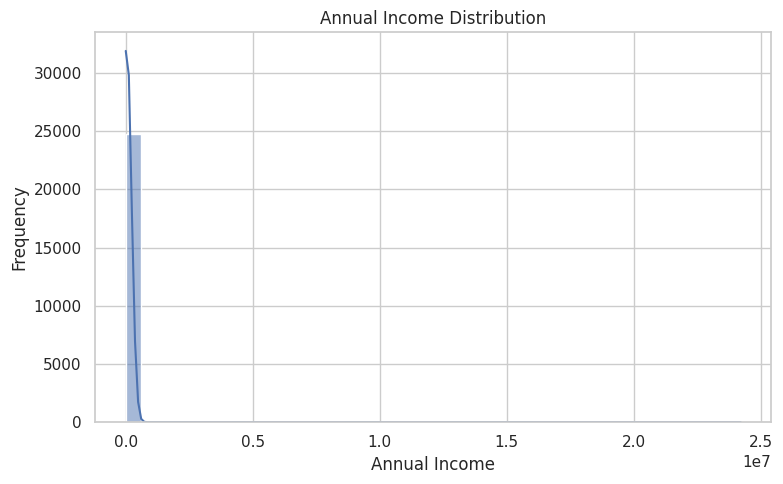

In [37]:
#Annual Income
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Annual_Income"],
    bins=40,
    kde=True
)

plt.title("Annual Income Distribution")

plt.xlabel("Annual Income")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

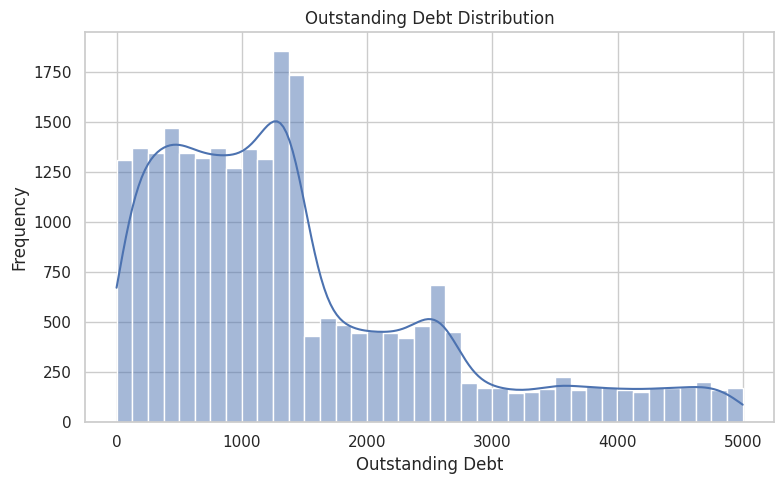

In [38]:
#Outstanding Debt
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Outstanding_Debt"],
    bins=40,
    kde=True
)

plt.title("Outstanding Debt Distribution")

plt.xlabel("Outstanding Debt")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

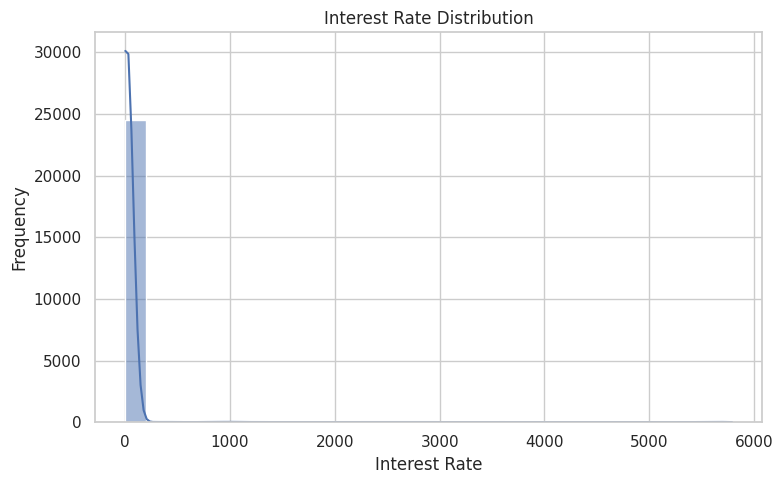

In [39]:
#Interest Rate
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Interest_Rate"],
    bins=30,
    kde=True
)

plt.title("Interest Rate Distribution")

plt.xlabel("Interest Rate")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

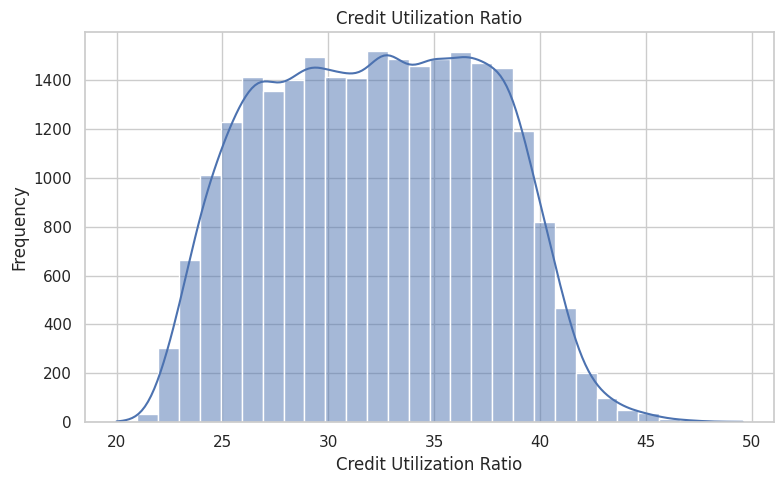

In [40]:
#Credit Utilization Ratio
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Credit_Utilization_Ratio"],
    bins=30,
    kde=True
)

plt.title("Credit Utilization Ratio")

plt.xlabel("Credit Utilization Ratio")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

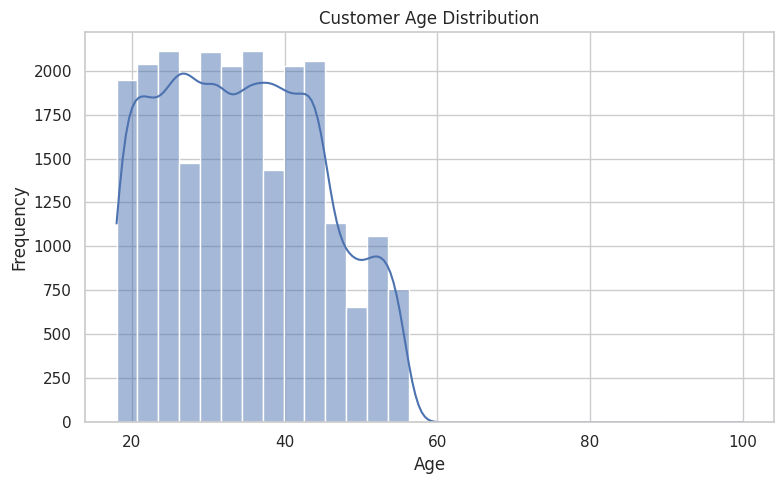

In [41]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Age"],
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

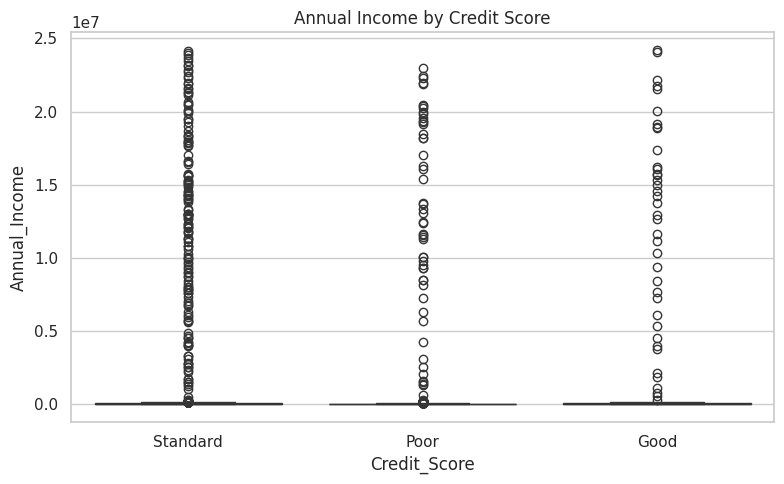

In [42]:
#Credit Score vs Annual Income
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Credit_Score",
    y="Annual_Income",
    palette="viridis"
)

plt.title("Annual Income by Credit Score")

plt.tight_layout()

plt.show()

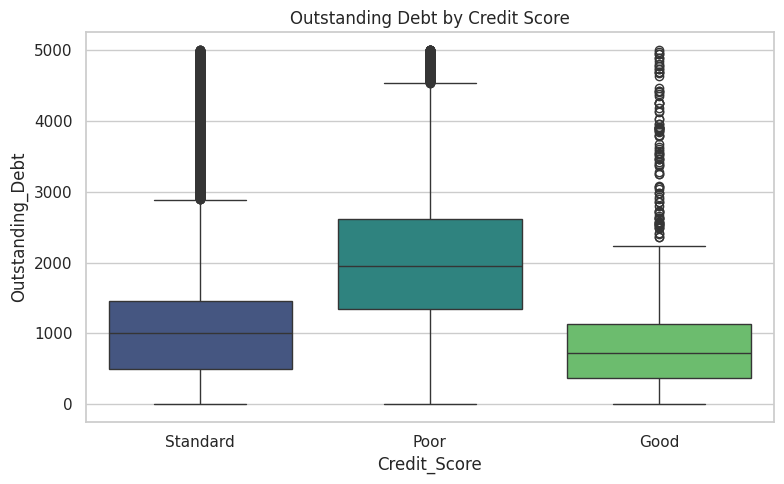

In [43]:
#Credit Score vs Outstanding Debt
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Credit_Score",
    y="Outstanding_Debt",
    palette="viridis"
)

plt.title("Outstanding Debt by Credit Score")

plt.tight_layout()

plt.show()

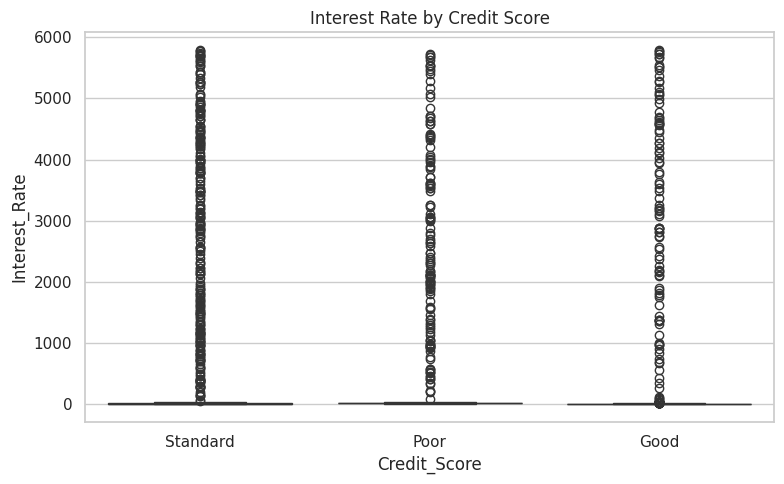

In [44]:
#Credit Score vs Interest Rate
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Credit_Score",
    y="Interest_Rate",
    palette="viridis"
)

plt.title("Interest Rate by Credit Score")

plt.tight_layout()

plt.show()

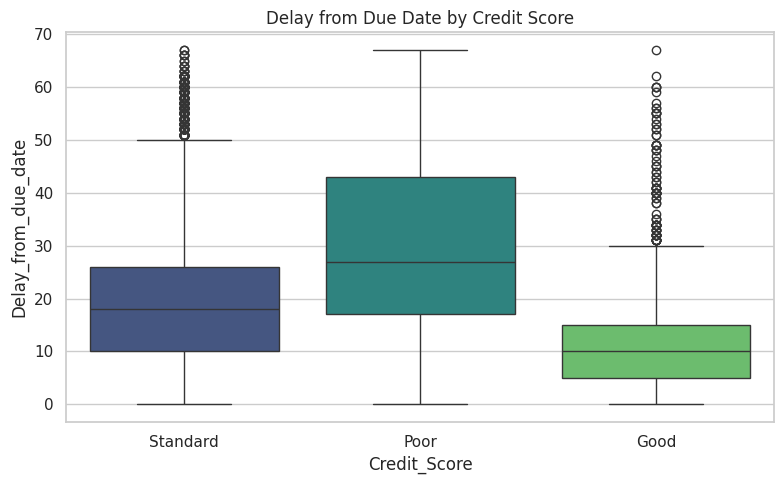

In [45]:
#Credit Score vs Delay from Due Date
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="Credit_Score",
    y="Delay_from_due_date",
    palette="viridis"
)

plt.title("Delay from Due Date by Credit Score")

plt.tight_layout()

plt.show()

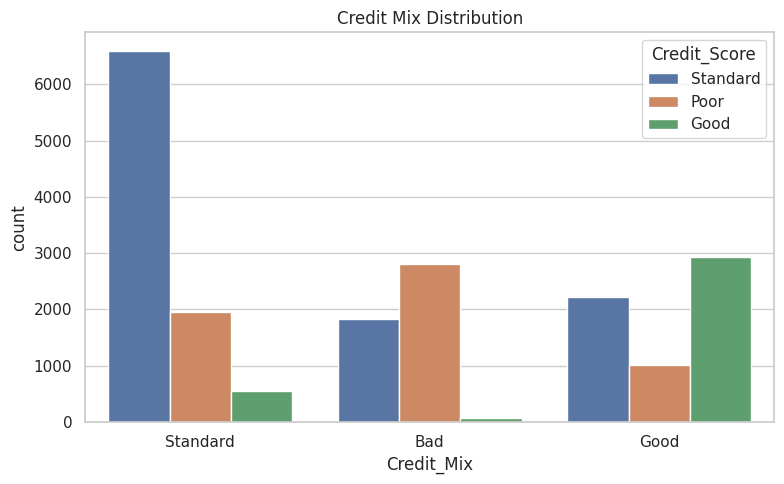

In [46]:
#Credit Mix Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x="Credit_Mix",
    hue="Credit_Score"
)

plt.title("Credit Mix Distribution")

plt.tight_layout()

plt.show()

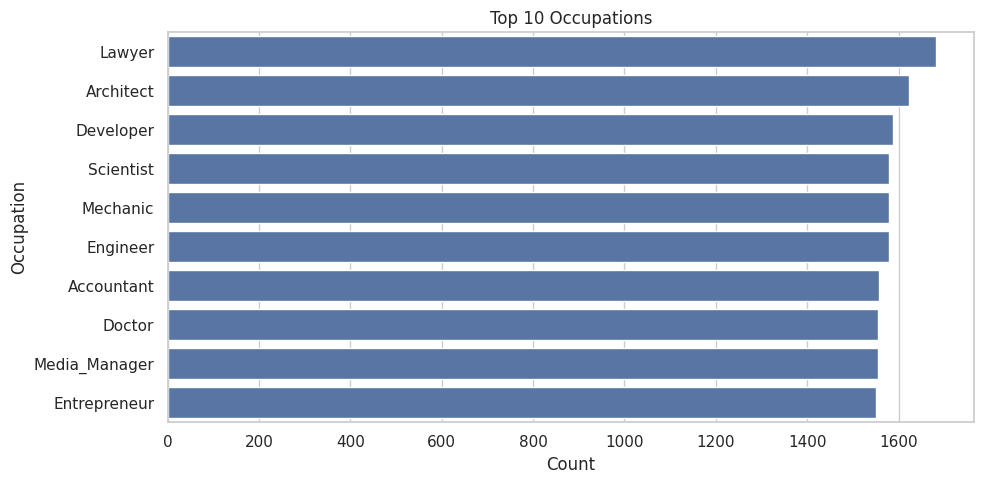

In [47]:
#Occupation Distribution
occupation_counts = (
    df_clean["Occupation"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=occupation_counts.values,
    y=occupation_counts.index
)

plt.title("Top 10 Occupations")

plt.xlabel("Count")

plt.ylabel("Occupation")

plt.tight_layout()

plt.show()

**Data Preparation and Preprocessing**

**Separate Features and Target**

In [48]:
TARGET = "Credit_Score"

X = df_clean.drop(columns=TARGET)
y = df_clean[TARGET]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (25000, 23)
Target Shape         : (25000,)


**Encoding**

In [49]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Encoded Classes")
for index, label in enumerate(label_encoder.classes_):
    print(f"{index} --> {label}")

Encoded Classes
0 --> Good
1 --> Poor
2 --> Standard


**Train Test Split**

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Set")
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print()

print("Testing Set")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

Training Set
X_train : (20000, 23)
y_train : (20000,)

Testing Set
X_test  : (5000, 23)
y_test  : (5000,)


**Identify Feature Types**

In [51]:
numerical_features = (
    X_train
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(include="object")
    .columns
    .tolist()
)

print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 17
Categorical Features : 6


**Display Feature Lists**

In [52]:
display(
    pd.DataFrame(
        numerical_features,
        columns=["Numerical Features"]
    )
)

display(
    pd.DataFrame(
        categorical_features,
        columns=["Categorical Features"]
    )
)

,Numerical Features
0,Age
1,Annual_Income
2,Monthly_Inhand_Salary
3,Num_Bank_Accounts
4,Num_Credit_Card
5,Interest_Rate
6,Num_of_Loan
7,Delay_from_due_date
8,Num_of_Delayed_Payment
9,Changed_Credit_Limit


,Categorical Features
0,Month
1,Occupation
2,Type_of_Loan
3,Credit_Mix
4,Payment_of_Min_Amount
5,Payment_Behaviour


**Numerical Pipeline**

In [53]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

**Categorical Pipeline**

In [54]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

**Column Transformer**

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("ColumnTransformer Created Successfully")

ColumnTransformer Created Successfully


**Fitting Dataset**

In [56]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test)

print("Training data transformed successfully.")
print("Testing data transformed successfully.")

Training data transformed successfully.
Testing data transformed successfully.


**Veirfy Missing Value**

In [57]:
if hasattr(X_train_processed, "toarray"):
    train_array = X_train_processed.toarray()
else:
    train_array = X_train_processed

if hasattr(X_test_processed, "toarray"):
    test_array = X_test_processed.toarray()
else:
    test_array = X_test_processed

print("Remaining Missing Values")
print("-" * 35)
print(f"Training Set : {np.isnan(train_array).sum()}")
print(f"Testing Set  : {np.isnan(test_array).sum()}")

Remaining Missing Values
-----------------------------------
Training Set : 0
Testing Set  : 0


**Check Final Feature**

In [58]:
print("Processed Dataset Shape")
print(f"Training : {X_train_processed.shape}")
print(f"Testing  : {X_test_processed.shape}")

Processed Dataset Shape
Training : (20000, 5334)
Testing  : (5000, 5334)


**Modelling**  
Dalam penelitian ini, empat algoritma *machine learning* digunakan sebagai model *baseline*, yaitu **Logistic Regression**, **Decision Tree**, **Random Forest**, dan **XGBoost**. Keempat model dipilih karena mewakili pendekatan pembelajaran yang berbeda dan telah banyak digunakan pada permasalahan klasifikasi, khususnya *credit scoring*. **Logistic Regression** digunakan sebagai model *baseline* yang sederhana dan mudah diinterpretasikan. **Decision Tree** dipilih karena mampu menangkap hubungan non-linear dan menghasilkan aturan keputusan yang mudah dipahami. **Random Forest** digunakan karena dapat meningkatkan performa prediksi melalui metode *ensemble* serta mengurangi risiko *overfitting*. Sementara itu, **XGBoost** dipilih karena dikenal memiliki akurasi tinggi dan sangat efektif untuk data tabular. Perbandingan keempat model ini bertujuan untuk menentukan model dengan performa terbaik berdasarkan metrik evaluasi sebelum dilakukan proses *hyperparameter tuning*.


In [59]:
models = {
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    )
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="mlogloss"
    )

print(f"Total Models : {len(models)}")

Total Models : 4


**Training Function**

In [60]:
def evaluate_model(model_name, model):
    """
    Train and evaluate a model.

    Returns
    -------
    dict
    """

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # Training
    start_time = time.time()

    pipeline.fit(X_train, y_train)

    training_time = time.time() - start_time

    # Prediction
    y_pred = pipeline.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (s)": training_time,
        "Pipeline": pipeline,
        "Predictions": y_pred
    }

**Training**

In [61]:
results = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    results[model_name] = evaluate_model(
        model_name,
        model
    )

print("\nTraining Completed.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...

Training Completed.


**Comparison Table (Baseline)**

In [62]:
comparison_df = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key not in ["Pipeline", "Predictions"]
    }
    for result in results.values()
])

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,Random Forest,0.72,0.72,0.72,0.72,42.69
1,XGBoost,0.71,0.71,0.71,0.71,3.17
2,Logistic Regression,0.67,0.67,0.67,0.67,13.92
3,Decision Tree,0.65,0.65,0.65,0.65,5.43


**Best Baseline Model**

In [63]:
best_model_name = max(
    results,
    key=lambda name: results[name]["F1 Score"]
)

best_result = results[best_model_name]
best_pipeline = best_result["Pipeline"]
best_predictions = best_result["Predictions"]
best_classifier = models[best_model_name]

print("=" * 60)
print("BEST BASELINE MODEL")
print("=" * 60)

print(f"Model             : {best_model_name}")
print(f"Accuracy          : {best_result['Accuracy']:.4f}")
print(f"Precision         : {best_result['Precision']:.4f}")
print(f"Recall            : {best_result['Recall']:.4f}")
print(f"Weighted F1 Score : {best_result['F1 Score']:.4f}")

BEST BASELINE MODEL
Model             : Random Forest
Accuracy          : 0.7192
Precision         : 0.7184
Recall            : 0.7192
Weighted F1 Score : 0.7186


Berdasarkan hasil perbandingan model baseline, Random Forest memperoleh weighted F1-score tertinggi dengan tetap mempertahankan nilai precision dan recall yang kompetitif. Oleh karena itu, Random Forest dipilih sebagai model yang akan dioptimalkan lebih lanjut melalui proses hyperparameter tuning menggunakan RandomizedSearchCV.

**Baseline Performance Summary**

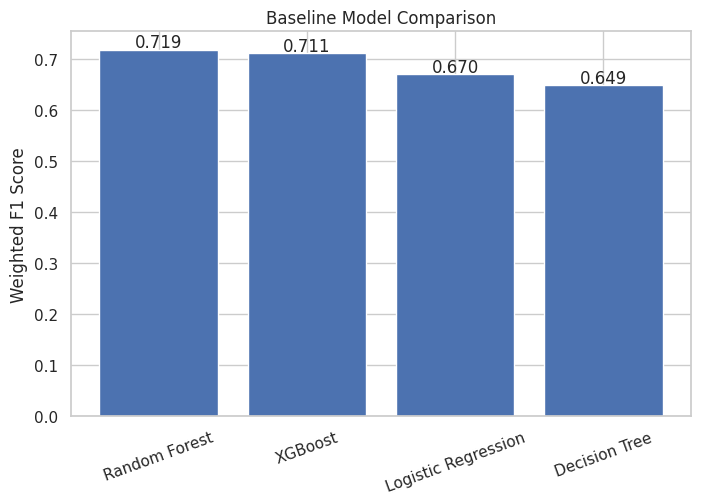

In [64]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["F1 Score"]
)

plt.title("Baseline Model Comparison")
plt.ylabel("Weighted F1 Score")
plt.xticks(rotation=20)

for index, score in enumerate(comparison_df["F1 Score"]):

    plt.text(
        index,
        score + 0.005,
        f"{score:.3f}",
        ha="center"
    )

plt.show()

**Model Evaluation and Hyperparameter Tuning**

**Classification Report (Baseline)**

In [65]:
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Good       0.63      0.61      0.62       893
        Poor       0.72      0.70      0.71      1446
    Standard       0.75      0.77      0.76      2661

    accuracy                           0.72      5000
   macro avg       0.70      0.69      0.70      5000
weighted avg       0.72      0.72      0.72      5000



**Confusion Matrix (Baseline)**

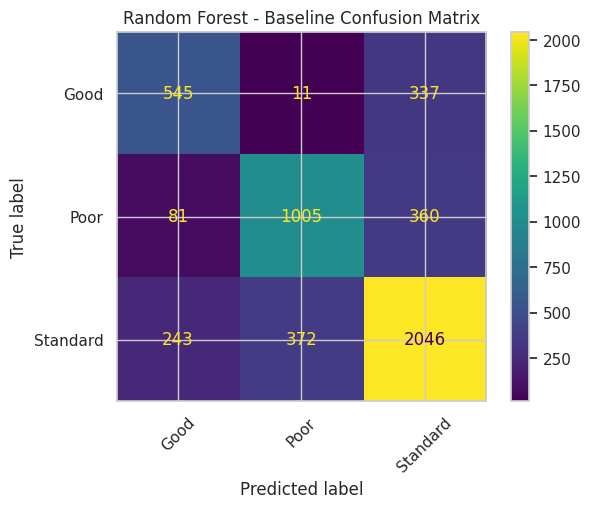

In [66]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title(f"{best_model_name} - Baseline Confusion Matrix")
plt.show()

**Cross Validation**

In [67]:
cv_scores = cross_val_score(
    best_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1_weighted",
    n_jobs=1
)

print("Cross Validation Results")
print(f"Fold Scores : {cv_scores}")
print(f"Mean Score  : {cv_scores.mean():.4f}")
print(f"Std Score   : {cv_scores.std():.4f}")

Cross Validation Results
Fold Scores : [0.69642915 0.70061273 0.70804655 0.70168937 0.68845059]
Mean Score  : 0.6990
Std Score   : 0.0065


**Hyperparameter Space**

In [68]:
param_grids = {

    "Logistic Regression": {
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__solver": ["lbfgs", "liblinear"],
        "classifier__penalty": ["l2"]
    },

    "Decision Tree": {
        "classifier__criterion": ["gini", "entropy"],
        "classifier__max_depth": [None, 5, 10, 20, 30],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "classifier__n_estimators": [100, 200, 300, 500],
        "classifier__max_depth": [None, 10, 20, 30],
        "classifier__min_samples_split": [2, 5, 10],
        "classifier__min_samples_leaf": [1, 2, 4],
        "classifier__max_features": ["sqrt", "log2"]
    },

    "XGBoost": {
        "classifier__n_estimators": [100, 200, 300],
        "classifier__max_depth": [3, 5, 7],
        "classifier__learning_rate": [0.01, 0.05, 0.1],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0]
    }
}

param_grid = param_grids[best_model_name]

**Build Tuning Pipeline**

In [69]:
tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", best_classifier)
])

**Randomized Search**

In [70]:
random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_grids[best_model_name],
    n_iter=15,
    cv=5,
    scoring="f1_weighted",
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1
)

start_time = time.time()
random_search.fit(
    X_train,
    y_train
)

tuning_time = time.time() - start_time
print("\nHyperparameter tuning completed.")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Hyperparameter tuning completed.


**Best Parameters**

In [71]:
print("=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)

for parameter, value in random_search.best_params_.items():
    print(f"{parameter} : {value}")

print()
print(f"Best CV F1 Score : {random_search.best_score_:.4f}")
print(f"Tuning Time      : {tuning_time:.2f} seconds")

BEST HYPERPARAMETERS
classifier__n_estimators : 200
classifier__min_samples_split : 10
classifier__min_samples_leaf : 1
classifier__max_features : sqrt
classifier__max_depth : None

Best CV F1 Score : 0.6955
Tuning Time      : 1033.46 seconds


**Save Tuned Pipeline**

In [72]:
best_pipeline = random_search.best_estimator_
best_predictions = best_pipeline.predict(X_test)

**Classification Report (Tuned)**

In [73]:
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Good       0.63      0.59      0.61       893
        Poor       0.72      0.70      0.71      1446
    Standard       0.74      0.77      0.75      2661

    accuracy                           0.72      5000
   macro avg       0.70      0.69      0.69      5000
weighted avg       0.71      0.72      0.71      5000



**Confusion Matrix (Tuned)**

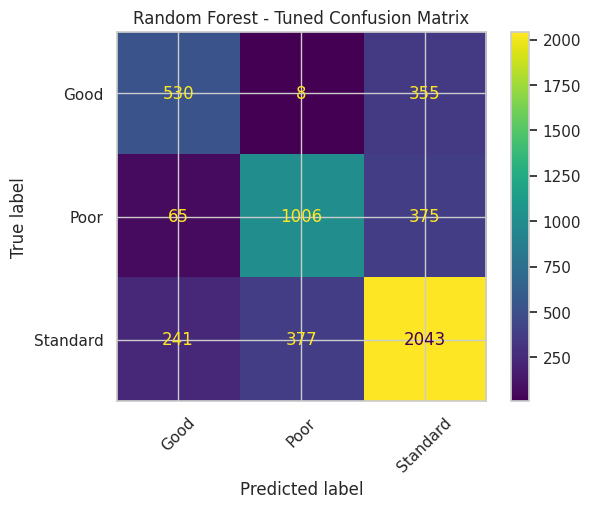

In [74]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=label_encoder.classes_,
    xticks_rotation=45
)

plt.title(f"{best_model_name} - Tuned Confusion Matrix")
plt.show()

**Final Evaluation**

In [75]:
evaluation_metrics = {

    "Accuracy": accuracy_score(
        y_test,
        best_predictions
    ),

    "Precision": precision_score(
        y_test,
        best_predictions,
        average="weighted",
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        best_predictions,
        average="weighted",
        zero_division=0
    ),

    "F1 Score": f1_score(
        y_test,
        best_predictions,
        average="weighted",
        zero_division=0
    )
}

evaluation_df = pd.DataFrame(
    evaluation_metrics.items(),
    columns=["Metric", "Score"]
)

display(evaluation_df)

,Metric,Score
0,Accuracy,0.72
1,Precision,0.71
2,Recall,0.72
3,F1 Score,0.71


**Comparison (Baseline vs Tuned)**

In [76]:
comparison_tuning = pd.DataFrame({
    "Model": [best_model_name],
    "Baseline F1 Score": [
        best_result["F1 Score"]
    ],
    "Tuned CV F1 Score": [
        random_search.best_score_
    ]
})

display(comparison_tuning)

,Model,Baseline F1 Score,Tuned CV F1 Score
0,Random Forest,0.72,0.70


**Performance Visualization**

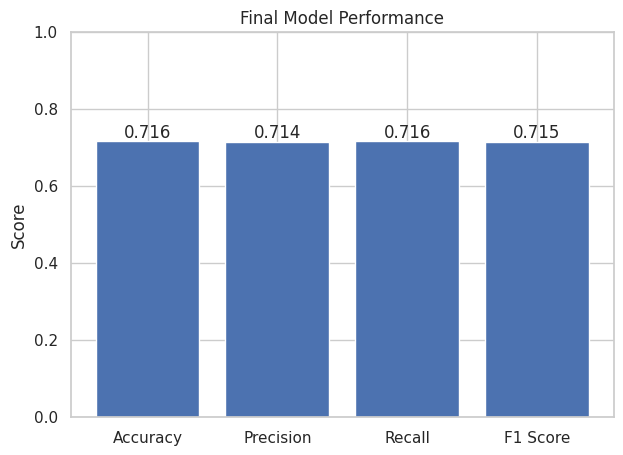

In [77]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    evaluation_df["Metric"],
    evaluation_df["Score"]
)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Final Model Performance")

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.3f}",
        ha="center"
    )

plt.show()

**Sample Predictions**

In [78]:
prediction_results = X_test.copy()

prediction_results["Actual"] = (
    label_encoder.inverse_transform(y_test)
)

prediction_results["Predicted"] = (
    label_encoder.inverse_transform(best_predictions)
)

prediction_results["Correct"] = (
    prediction_results["Actual"] ==
    prediction_results["Predicted"]
)

display(prediction_results.head(15))

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Actual,Predicted,Correct
21919,June,41.00,Journalist,19620.30,1866.03,3,5,14,3.00,"Not Specified, Payday Loan, and Home Equity Loan",21,8.00,10.45,4.00,Standard,168.00,34.75,207.00,Yes,36.97,51.55,High_spent_Medium_value_payments,348.09,Standard,Standard,True
12156,January,NaN,Musician,70097.54,5850.46,5,5,20,1.00,Debt Consolidation Loan,30,9.00,6.02,6.00,Standard,229.36,32.77,361.00,Yes,53.38,66.68,High_spent_Large_value_payments,704.98,Standard,Standard,True
18771,May,29.00,Manager,18285.06,1238.76,5,1030,22,4.00,"Payday Loan, Home Equity Loan, Mortgage Loan, ...",22,13.00,16.25,11.00,Standard,2541.81,24.44,171.00,Yes,39.72,78.00,Low_spent_Small_value_payments,296.16,Poor,Poor,True
2833,August,18.00,NaN,10203.99,1119.33,6,10,30,3.00,"Credit-Builder Loan, Home Equity Loan, and Stu...",15,8.00,8.53,12.00,Standard,1710.59,29.96,68.00,Yes,16.58,NaN,Low_spent_Large_value_payments,306.13,Poor,Poor,True
24600,January,31.00,Manager,40214.54,NaN,3,5,21,3.00,"Credit-Builder Loan, Debt Consolidation Loan, ...",26,15.00,11.99,9.00,NaN,1997.76,32.20,147.00,Yes,71.41,109.39,High_spent_Medium_value_payments,416.22,Poor,Poor,True
24484,April,20.00,Architect,38840.66,3442.72,8,5,30,4.00,"Mortgage Loan, Student Loan, Auto Loan, and Cr...",65,25.00,3.17,10.00,Bad,2529.34,28.10,202.00,Yes,125.99,283.40,Low_spent_Large_value_payments,204.88,Poor,Poor,True
8714,April,43.00,Mechanic,60036.75,5279.06,7,8,34,5.00,"Not Specified, Not Specified, Credit-Builder L...",46,15.00,26.90,15.00,Bad,3563.38,33.26,120.00,Yes,147.59,170.91,High_spent_Small_value_payments,469.40,Standard,Standard,True
14242,May,22.00,NaN,18145.22,1459.10,4,3,10,1.00,Home Equity Loan,3,NaN,4.36,2.00,Good,1154.49,35.85,NaN,No,12.84,60.24,High_spent_Small_value_payments,332.83,Good,Standard,False
24762,March,39.00,Journalist,151623.56,12461.30,4,4,1,3.00,"Home Equity Loan, Mortgage Loan, and Home Equi...",0,7.00,8.11,1.00,Good,413.28,42.13,273.00,No,216.07,216.47,High_spent_Large_value_payments,1053.59,Good,Good,True
4005,August,23.00,Scientist,44178.15,3446.51,4,3,6,4.00,"Not Specified, Auto Loan, Home Equity Loan, an...",0,1.00,12.08,4.00,Good,300.68,29.41,216.00,No,123.55,307.20,Low_spent_Large_value_payments,183.90,Standard,Good,False


**Misclassified Samples**

In [79]:
misclassified = prediction_results[
    prediction_results["Correct"] == False
]

print(f"Total Misclassified Samples : {len(misclassified)}")

display(
    misclassified.head(10)
)

Total Misclassified Samples : 1421


,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Actual,Predicted,Correct
14242,May,22.00,NaN,18145.22,1459.10,4,3,10,1.00,Home Equity Loan,3,NaN,4.36,2.00,Good,1154.49,35.85,NaN,No,12.84,60.24,High_spent_Small_value_payments,332.83,Good,Standard,False
4005,August,23.00,Scientist,44178.15,3446.51,4,3,6,4.00,"Not Specified, Auto Loan, Home Equity Loan, an...",0,1.00,12.08,4.00,Good,300.68,29.41,216.00,No,123.55,307.20,Low_spent_Large_value_payments,183.90,Standard,Good,False
17011,January,44.00,Developer,44328.93,3452.08,8,8,18,9.00,"Personal Loan, Personal Loan, Auto Loan, Credi...",51,22.00,18.04,7.00,Bad,4633.42,27.12,64.00,Yes,288.12,448.61,Low_spent_Small_value_payments,NaN,Poor,Standard,False
15539,August,33.00,Media_Manager,30874.43,2595.87,4,5,8,2.00,"Mortgage Loan, and Credit-Builder Loan",10,5.00,3.82,2.00,Good,243.11,26.64,266.00,NaN,48.27,67.91,High_spent_Small_value_payments,403.41,Poor,Standard,False
11230,February,28.00,Developer,75524.26,6118.69,2,5,5686,4.00,"Home Equity Loan, Mortgage Loan, Personal Loan...",15,4.00,14.14,0.00,Good,852.62,41.61,191.00,No,167.29,250.53,High_spent_Small_value_payments,454.05,Standard,Good,False
24336,January,26.00,Lawyer,39693.86,3449.82,0,2,1,2.00,"Credit-Builder Loan, and Payday Loan",0,13.00,1.69,3.00,Good,306.03,34.88,214.00,No,50.41,45.88,High_spent_Large_value_payments,488.69,Standard,Good,False
13569,April,21.00,Writer,15475.27,1264.61,6,6,28,6.00,"Student Loan, Debt Consolidation Loan, Auto Lo...",39,16.00,23.33,NaN,Bad,4683.73,40.56,167.00,Yes,42.09,103.48,Low_spent_Small_value_payments,270.89,Standard,Poor,False
2295,August,22.00,Developer,18289.68,1305.14,6,9,26,8.00,"Mortgage Loan, Payday Loan, Debt Consolidation...",42,17.00,26.39,10.00,NaN,4266.37,22.91,NaN,NaN,99.10,62.58,Low_spent_Large_value_payments,238.83,Poor,Standard,False
18604,May,50.00,Journalist,140390.32,11888.19,5,2,4,3.00,"Credit-Builder Loan, Home Equity Loan, and Pay...",3,0.00,4.67,6.00,Good,1423.23,34.12,372.00,No,182.16,200.26,High_spent_Large_value_payments,1046.39,Standard,Good,False
10,June,40.00,Journalist,21139.23,1646.60,5,5,7,4.00,"Personal Loan, Not Specified, Student Loan, an...",23,10.00,2.75,4.00,Standard,298.50,27.82,380.00,No,66.90,NaN,Low_spent_Large_value_payments,248.78,Poor,Standard,False
